# Chapter 2, Session 1: Parquet Deep Dive

**Goal:** Understand columnar storage by doing — not just reading about it.

We'll use our FineWeb sample (5000 docs) and:
1. Save it in 3 formats (CSV, JSONL, Parquet) and compare sizes
2. Explore Parquet internals — row groups, column chunks, metadata
3. Test compression algorithms (Snappy, ZSTD, Gzip, None) and measure differences
4. Prove column pruning is faster with a benchmark
5. See the small files problem and how to fix it
6. Practice partition pruning

## Step 1: Load Our FineWeb Data

In [1]:
import pickle
import pandas as pd

with open('../data/fineweb_5000_samples.pkl', 'rb') as f:
    samples = pickle.load(f)

df = pd.DataFrame(samples)
print(f"Loaded {len(df)} documents")
print(f"Columns: {list(df.columns)}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

Loaded 5000 documents
Columns: ['text', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'token_count']

Memory usage: 16.2 MB


## Step 2: Format Showdown — CSV vs JSONL vs Parquet

Let's save the exact same data in 3 formats and compare file sizes.

**Prediction before you run this:** Which do you think will be smallest? Largest?

In [2]:
import os
import json
import time

os.makedirs('../data/format_comparison', exist_ok=True)

# --- CSV ---
start = time.time()
df.to_csv('../data/format_comparison/fineweb.csv', index=False)
csv_write_time = time.time() - start
csv_size = os.path.getsize('../data/format_comparison/fineweb.csv')

# --- JSONL ---
start = time.time()
with open('../data/format_comparison/fineweb.jsonl', 'w') as f:
    for record in samples:
        f.write(json.dumps(record) + '\n')
jsonl_write_time = time.time() - start
jsonl_size = os.path.getsize('../data/format_comparison/fineweb.jsonl')

# --- Parquet (default snappy compression) ---
start = time.time()
df.to_parquet('../data/format_comparison/fineweb.parquet')
parquet_write_time = time.time() - start
parquet_size = os.path.getsize('../data/format_comparison/fineweb.parquet')

# Results
print(f"{'Format':<12} {'Size (MB)':>10} {'Write Time':>12} {'vs Parquet':>12}")
print('-' * 48)
print(f"{'CSV':<12} {csv_size/1024/1024:>10.2f} {csv_write_time:>10.2f}s {csv_size/parquet_size:>11.1f}x")
print(f"{'JSONL':<12} {jsonl_size/1024/1024:>10.2f} {jsonl_write_time:>10.2f}s {jsonl_size/parquet_size:>11.1f}x")
print(f"{'Parquet':<12} {parquet_size/1024/1024:>10.2f} {parquet_write_time:>10.2f}s {'1.0x':>12}")

Format        Size (MB)   Write Time   vs Parquet
------------------------------------------------
CSV               16.07       0.36s         1.7x
JSONL             16.86       0.30s         1.8x
Parquet            9.54       0.19s         1.0x


**Why is Parquet smaller?**
- CSV/JSONL repeat column names and formatting for every single row
- JSONL: `{"text": "...", "id": "...", "url": "..."}` — those keys are repeated 5000 times
- CSV: quoting, escaping newlines in text fields adds overhead
- Parquet: stores each column together, applies Snappy compression per column chunk

## Step 3: Parquet Internals — Look Inside the File

Let's use PyArrow to inspect the actual structure of our Parquet file.

In [3]:
import pyarrow.parquet as pq

# Read the Parquet file's metadata (this does NOT read the actual data)
parquet_file = pq.ParquetFile('../data/format_comparison/fineweb.parquet')
metadata = parquet_file.metadata

print("=== Parquet File Metadata ===")
print(f"Number of row groups: {metadata.num_row_groups}")
print(f"Number of columns: {metadata.num_columns}")
print(f"Total rows: {metadata.num_rows}")
print(f"File size: {parquet_size / 1024 / 1024:.2f} MB")
print(f"Created by: {metadata.created_by}")

print(f"\n=== Schema ===")
print(parquet_file.schema_arrow)

=== Parquet File Metadata ===
Number of row groups: 1
Number of columns: 9
Total rows: 5000
File size: 9.54 MB
Created by: parquet-cpp-arrow version 23.0.0

=== Schema ===
text: large_string
id: large_string
dump: large_string
url: large_string
date: large_string
file_path: large_string
language: large_string
language_score: double
token_count: int64
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 1265


In [4]:
# Dive into Row Group 0 — see each column's size
rg = metadata.row_group(0)
print(f"=== Row Group 0 ===")
print(f"Rows: {rg.num_rows}")
print(f"Total byte size: {rg.total_byte_size / 1024 / 1024:.2f} MB")

print(f"\n{'Column':<20} {'Type':<15} {'Compressed':>12} {'Uncompressed':>14} {'Ratio':>8}")
print('-' * 72)
for i in range(rg.num_columns):
    col = rg.column(i)
    compressed = col.total_compressed_size
    uncompressed = col.total_uncompressed_size
    ratio = uncompressed / compressed if compressed > 0 else 0
    name = col.path_in_schema
    print(f"{name:<20} {str(col.physical_type):<15} {compressed/1024:>10.1f} KB {uncompressed/1024:>12.1f} KB {ratio:>7.1f}x")

=== Row Group 0 ===
Rows: 5000
Total byte size: 15.53 MB

Column               Type              Compressed   Uncompressed    Ratio
------------------------------------------------------------------------
text                 BYTE_ARRAY          9169.3 KB      14902.9 KB     1.6x
id                   BYTE_ARRAY           185.9 KB        257.1 KB     1.4x
dump                 BYTE_ARRAY             0.2 KB          0.3 KB     1.3x
url                  BYTE_ARRAY           270.7 KB        391.0 KB     1.4x
date                 BYTE_ARRAY            48.0 KB        124.9 KB     2.6x
file_path            BYTE_ARRAY            38.4 KB        156.1 KB     4.1x
language             BYTE_ARRAY             0.1 KB          0.1 KB     0.9x
language_score       DOUBLE                35.7 KB         47.0 KB     1.3x
token_count          INT64                 13.0 KB         18.9 KB     1.5x


**What to notice above:**
- The `text` column dominates — it's where all the web page content lives
- Small columns like `language_score` (just a float per row) compress extremely well
- The compression ratio varies per column — this is why columnar beats row storage for compression

## Step 4: Compression Showdown

Let's write the same data with different compression algorithms and compare.

Remember from the chapter:
- **Snappy** — fast, moderate compression (default)
- **LZ4** — fastest, lowest compression
- **ZSTD** — slowest write, best compression
- **Gzip** — legacy, high compatibility
- **None** — raw, no compression

In [5]:
import pyarrow as pa
import pyarrow.parquet as pq

table = pa.Table.from_pandas(df)
compressions = ['NONE', 'SNAPPY', 'GZIP', 'ZSTD', 'LZ4']
results = []

for comp in compressions:
    path = f'../data/format_comparison/fineweb_{comp.lower()}.parquet'
    
    # Write
    start = time.time()
    pq.write_table(table, path, compression=comp)
    write_time = time.time() - start
    
    # Read
    start = time.time()
    _ = pq.read_table(path)
    read_time = time.time() - start
    
    size = os.path.getsize(path)
    results.append({
        'compression': comp,
        'size_mb': size / 1024 / 1024,
        'write_s': write_time,
        'read_s': read_time,
    })

res_df = pd.DataFrame(results)
none_size = res_df[res_df['compression'] == 'NONE']['size_mb'].values[0]
res_df['ratio'] = none_size / res_df['size_mb']

print(f"{'Compression':<12} {'Size (MB)':>10} {'Ratio':>8} {'Write (s)':>10} {'Read (s)':>10}")
print('-' * 52)
for _, r in res_df.iterrows():
    print(f"{r['compression']:<12} {r['size_mb']:>10.2f} {r['ratio']:>7.1f}x {r['write_s']:>10.3f} {r['read_s']:>10.3f}")

Compression   Size (MB)    Ratio  Write (s)   Read (s)
----------------------------------------------------
NONE              15.53     1.0x      0.048      0.150
SNAPPY             9.54     1.6x      0.310      0.066
GZIP               6.21     2.5x      1.252      0.140
ZSTD               6.82     2.3x      0.118      0.039
LZ4                9.87     1.6x      0.087      0.033


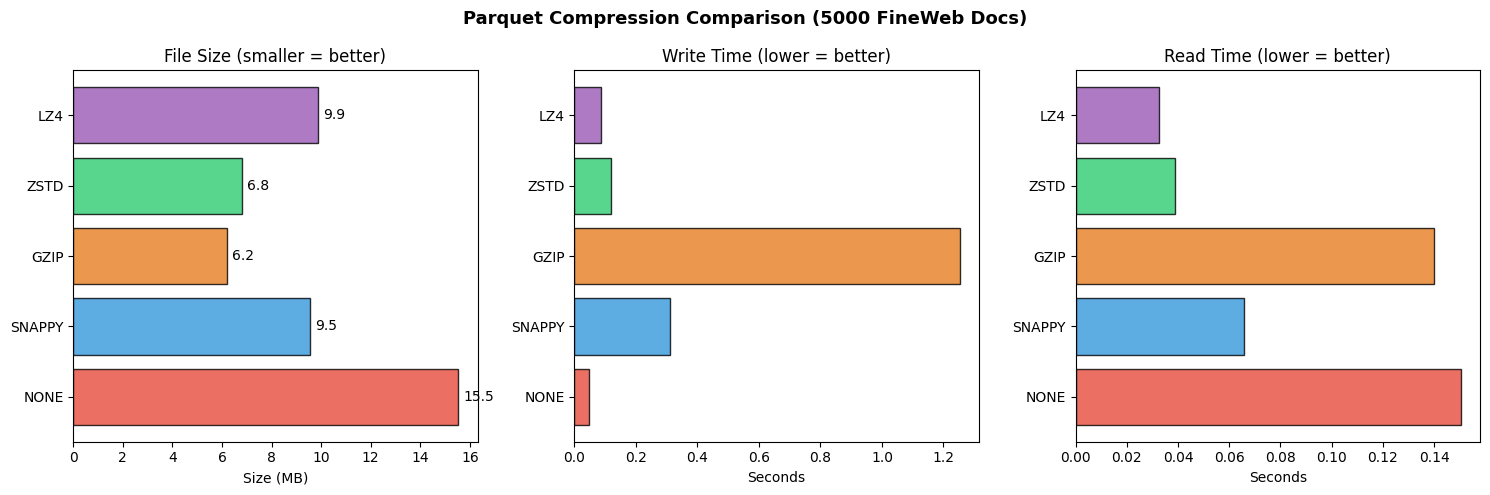

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Parquet Compression Comparison (5000 FineWeb Docs)', fontsize=13, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#e67e22', '#2ecc71', '#9b59b6']

# File size
axes[0].barh(res_df['compression'], res_df['size_mb'], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Size (MB)')
axes[0].set_title('File Size (smaller = better)')
for i, v in enumerate(res_df['size_mb']):
    axes[0].text(v + 0.2, i, f'{v:.1f}', va='center')

# Write speed
axes[1].barh(res_df['compression'], res_df['write_s'], color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Seconds')
axes[1].set_title('Write Time (lower = better)')

# Read speed
axes[2].barh(res_df['compression'], res_df['read_s'], color=colors, edgecolor='black', alpha=0.8)
axes[2].set_xlabel('Seconds')
axes[2].set_title('Read Time (lower = better)')

plt.tight_layout()
plt.savefig('../data/compression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Key takeaway:** See the tradeoff yourself:
- ZSTD gives best compression but costs more CPU time on write
- Snappy/LZ4 are fast but files are bigger
- This is why the chapter says: **hot data = Snappy/LZ4, cold data = ZSTD**

## Step 5: Column Pruning — Parquet's Superpower

This is the #1 reason Parquet matters for large datasets.

Let's prove it: read ALL columns vs read just ONE column, and time both.

In [7]:
parquet_path = '../data/format_comparison/fineweb_snappy.parquet'
jsonl_path = '../data/format_comparison/fineweb.jsonl'
N_RUNS = 5  # average over multiple runs for reliability

# --- Parquet: read ALL columns ---
times = []
for _ in range(N_RUNS):
    start = time.time()
    full = pq.read_table(parquet_path).to_pandas()
    times.append(time.time() - start)
pq_all_time = sum(times) / len(times)

# --- Parquet: read ONLY 'token_count' and 'language_score' ---
times = []
for _ in range(N_RUNS):
    start = time.time()
    partial = pq.read_table(parquet_path, columns=['token_count', 'language_score']).to_pandas()
    times.append(time.time() - start)
pq_cols_time = sum(times) / len(times)

# --- JSONL: read ONLY 'token_count' and 'language_score' ---
# (still has to parse every line to extract those fields)
times = []
for _ in range(N_RUNS):
    start = time.time()
    records = []
    with open(jsonl_path) as f:
        for line in f:
            row = json.loads(line)
            records.append({'token_count': row['token_count'], 'language_score': row['language_score']})
    jsonl_df = pd.DataFrame(records)
    times.append(time.time() - start)
jsonl_cols_time = sum(times) / len(times)

print("=== Column Pruning Benchmark (avg of 5 runs) ===")
print(f"{'Operation':<45} {'Time':>8}")
print('-' * 55)
print(f"{'Parquet: read ALL columns':<45} {pq_all_time:>7.3f}s")
print(f"{'Parquet: read 2 columns only':<45} {pq_cols_time:>7.3f}s")
print(f"{'JSONL: read 2 columns (must parse all)':<45} {jsonl_cols_time:>7.3f}s")
print(f"\nParquet column pruning speedup: {pq_all_time/pq_cols_time:.1f}x faster than full read")
print(f"Parquet vs JSONL for 2 columns:  {jsonl_cols_time/pq_cols_time:.1f}x faster")

=== Column Pruning Benchmark (avg of 5 runs) ===
Operation                                         Time
-------------------------------------------------------
Parquet: read ALL columns                       0.033s
Parquet: read 2 columns only                    0.002s
JSONL: read 2 columns (must parse all)          0.051s

Parquet column pruning speedup: 15.9x faster than full read
Parquet vs JSONL for 2 columns:  24.8x faster


**Why this matters at scale:**
- Our dataset is 5000 docs. Imagine 5 billion.
- If you only need `token_count` to filter, Parquet skips reading the massive `text` column entirely
- JSONL *must* parse every character of every line, even if you only want one field
- At TB scale, this is the difference between a 5-minute query and a 5-hour query

## Step 6: The Small Files Problem

The book warns: "100,000 files of 1MB each is a disaster." Let's see why.

In [8]:
import shutil, os

# Create the "bad" approach: one file per 50 rows (100 tiny files)
small_dir = '../data/format_comparison/small_files'
big_dir = '../data/format_comparison/big_files'
os.makedirs(small_dir, exist_ok=True)
os.makedirs(big_dir, exist_ok=True)

# Write 100 small files
start = time.time()
for i in range(100):
    chunk = df.iloc[i*50:(i+1)*50]
    chunk.to_parquet(f'{small_dir}/part_{i:04d}.parquet')
small_write_time = time.time() - start

# Write 2 big files (2500 rows each)
start = time.time()
for i in range(2):
    chunk = df.iloc[i*2500:(i+1)*2500]
    chunk.to_parquet(f'{big_dir}/part_{i:04d}.parquet')
big_write_time = time.time() - start

# Read all small files
start = time.time()
dfs = []
for fname in sorted(os.listdir(small_dir)):
    dfs.append(pd.read_parquet(f'{small_dir}/{fname}'))
small_read = pd.concat(dfs)
small_read_time = time.time() - start

# Read big files
start = time.time()
dfs = []
for fname in sorted(os.listdir(big_dir)):
    dfs.append(pd.read_parquet(f'{big_dir}/{fname}'))
big_read = pd.concat(dfs)
big_read_time = time.time() - start

# File sizes
small_total = sum(os.path.getsize(f'{small_dir}/{f}') for f in os.listdir(small_dir))
big_total = sum(os.path.getsize(f'{big_dir}/{f}') for f in os.listdir(big_dir))

print("=== Small Files vs Big Files ===")
print(f"{'Metric':<25} {'100 small files':>18} {'2 big files':>18}")
print('-' * 63)
print(f"{'Total size':<25} {small_total/1024/1024:>17.2f}M {big_total/1024/1024:>17.2f}M")
print(f"{'Write time':<25} {small_write_time:>17.3f}s {big_write_time:>17.3f}s")
print(f"{'Read time':<25} {small_read_time:>17.3f}s {big_read_time:>17.3f}s")
print(f"{'Rows recovered':<25} {len(small_read):>18} {len(big_read):>18}")
print(f"\nSmall files are {small_total/big_total:.2f}x the total size (metadata overhead per file)")
print(f"Small files read {small_read_time/big_read_time:.1f}x slower")

=== Small Files vs Big Files ===
Metric                       100 small files        2 big files
---------------------------------------------------------------
Total size                            10.67M              9.55M
Write time                            0.360s             0.232s
Read time                             0.480s             0.089s
Rows recovered                          5000               5000

Small files are 1.12x the total size (metadata overhead per file)
Small files read 5.4x slower


**Why small files are bad:**
- Each Parquet file has a **footer** with schema + metadata — duplicated across 100 files
- Each file open/close is a system call — 100x overhead
- On S3, each `ListObjects` call returns max 1000 keys — 100k files = 100 API calls just to list them
- **Rule of thumb: target 128MB–1GB per Parquet file**

## Step 7: Partition Pruning

Partitioning = organizing files into folders by a column value.

Instead of one giant file, you get:
```
data/
  language=en/
    part-00000.parquet
  language=de/
    part-00000.parquet
  language=fr/
    part-00000.parquet
```

Query `WHERE language = 'en'`? Only reads the `en/` folder. Skips everything else.

In [9]:
# Our data has a 'language' column — let's see what values exist
print("Language distribution:")
print(df['language'].value_counts().head(10))

# Also check the 'dump' column (Common Crawl dump identifier)
print(f"\nUnique dumps: {df['dump'].nunique()}")
print(df['dump'].value_counts().head(5))

Language distribution:
language
en    5000
Name: count, dtype: int64

Unique dumps: 8
dump
CC-MAIN-2017-34    779
CC-MAIN-2015-14    731
CC-MAIN-2013-20    704
CC-MAIN-2016-30    646
CC-MAIN-2019-35    622
Name: count, dtype: int64


In [10]:
# Write partitioned by 'dump' (Common Crawl dump date)
partition_dir = '../data/format_comparison/partitioned'
if os.path.exists(partition_dir):
    shutil.rmtree(partition_dir)

table = pa.Table.from_pandas(df)
pq.write_to_dataset(table, partition_dir, partition_cols=['dump'])

# See the folder structure
print("=== Partitioned Directory Structure ===")
for root, dirs, files in os.walk(partition_dir):
    level = root.replace(partition_dir, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root)
    if files:
        total_size = sum(os.path.getsize(os.path.join(root, f)) for f in files)
        print(f"{indent}{folder_name}/ ({len(files)} files, {total_size/1024:.0f} KB)")
    else:
        print(f"{indent}{folder_name}/")

=== Partitioned Directory Structure ===
partitioned/
  dump=CC-MAIN-2016-30/ (1 files, 1271 KB)
  dump=CC-MAIN-2022-21/ (1 files, 1188 KB)
  dump=CC-MAIN-2018-34/ (1 files, 914 KB)
  dump=CC-MAIN-2020-45/ (1 files, 840 KB)
  dump=CC-MAIN-2019-35/ (1 files, 1311 KB)
  dump=CC-MAIN-2017-34/ (1 files, 1493 KB)
  dump=CC-MAIN-2013-20/ (1 files, 1405 KB)
  dump=CC-MAIN-2015-14/ (1 files, 1414 KB)


In [11]:
# Benchmark: read ALL partitions vs read ONE partition
# Pick one dump value to filter on
target_dump = df['dump'].value_counts().index[0]  # most common dump

# Read everything (no filter)
times = []
for _ in range(N_RUNS):
    start = time.time()
    full = pq.read_table(partition_dir).to_pandas()
    times.append(time.time() - start)
full_time = sum(times) / len(times)

# Read with partition filter (only one dump)
times = []
for _ in range(N_RUNS):
    start = time.time()
    filtered = pq.read_table(partition_dir, 
                              filters=[('dump', '=', target_dump)]).to_pandas()
    times.append(time.time() - start)
filter_time = sum(times) / len(times)

print(f"=== Partition Pruning Benchmark ===")
print(f"Target dump: {target_dump}")
print(f"Full read (all dumps): {len(full)} rows in {full_time:.3f}s")
print(f"Filtered read (one dump): {len(filtered)} rows in {filter_time:.3f}s")
print(f"\nSpeedup: {full_time/filter_time:.1f}x faster")
print(f"Data scanned: {len(filtered)/len(full)*100:.1f}% of total")

=== Partition Pruning Benchmark ===
Target dump: CC-MAIN-2017-34
Full read (all dumps): 5000 rows in 0.021s
Filtered read (one dump): 779 rows in 0.010s

Speedup: 2.0x faster
Data scanned: 15.6% of total


**When to partition:**
- Partition by columns you frequently filter on (date, language, source)
- Partition column should be **low cardinality** (10-100 values, not 1 million)
- High cardinality (like user_id) = too many tiny folders = small files problem again

**Real-world example:** FineWeb is partitioned by Common Crawl dump date — when you only need the latest crawl, you skip reading years of old data.

## Step 8: Summary — When to Use What

| Scenario | Format | Compression | Why |
|----------|--------|-------------|-----|
| Pre-training text corpus | Parquet | Snappy | Columnar pruning + fast reads |
| SFT instruction data (10k examples) | JSONL | None/Gzip | Small, human-readable, easy to inspect |
| Image-text pairs (LAION) | WebDataset | Within TAR | Groups related files, streaming reads |
| Archive data (won't read for months) | Parquet | ZSTD | Max compression, storage savings |
| Data you're actively developing | Parquet | Snappy/LZ4 | Fast iteration |

### Parquet Optimization Checklist:
1. **Column pruning** — only read columns you need (`columns=['text', 'score']`)
2. **Partition pruning** — organize by date/language, filter at read time
3. **File size** — target 128MB-1GB per file, never thousands of tiny files
4. **Compression** — Snappy for hot data, ZSTD for cold storage

In [12]:
# Cleanup temp files to save disk
import shutil
for d in ['small_files', 'big_files', 'partitioned']:
    path = f'../data/format_comparison/{d}'
    if os.path.exists(path):
        shutil.rmtree(path)
# Keep the format comparison files for future reference
print("Cleaned up temp directories. Kept format comparison files.")
print("\nSession 1 complete! You now understand:")
print("  - Why columnar storage beats row storage")
print("  - How Parquet files are structured internally")
print("  - The real tradeoffs between compression algorithms")
print("  - Column pruning, partition pruning, and the small files problem")

Cleaned up temp directories. Kept format comparison files.

Session 1 complete! You now understand:
  - Why columnar storage beats row storage
  - How Parquet files are structured internally
  - The real tradeoffs between compression algorithms
  - Column pruning, partition pruning, and the small files problem
